In [ ]:
import pandas as pd
df = pd.read_csv("glass.csv")
df


['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df=df.drop_duplicates()
df

In [ ]:
list(df)

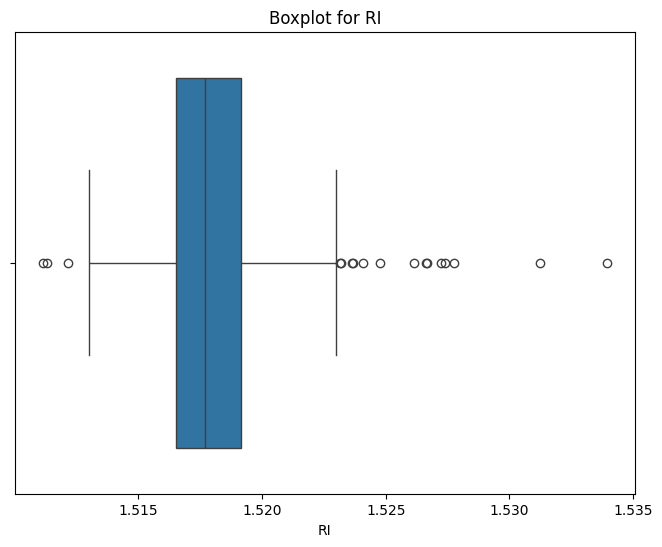

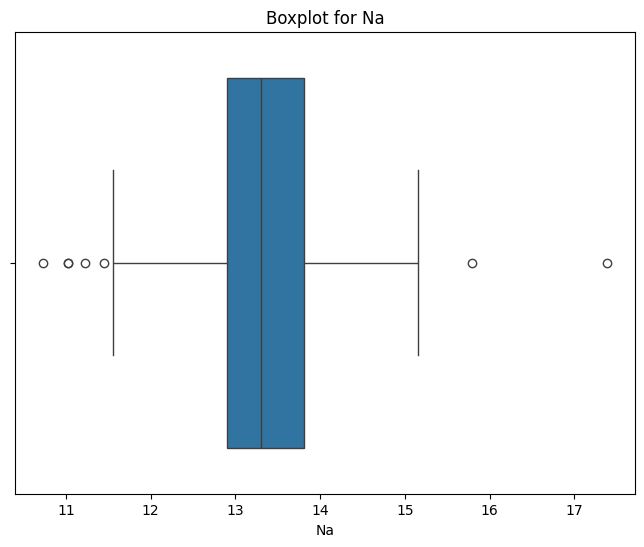

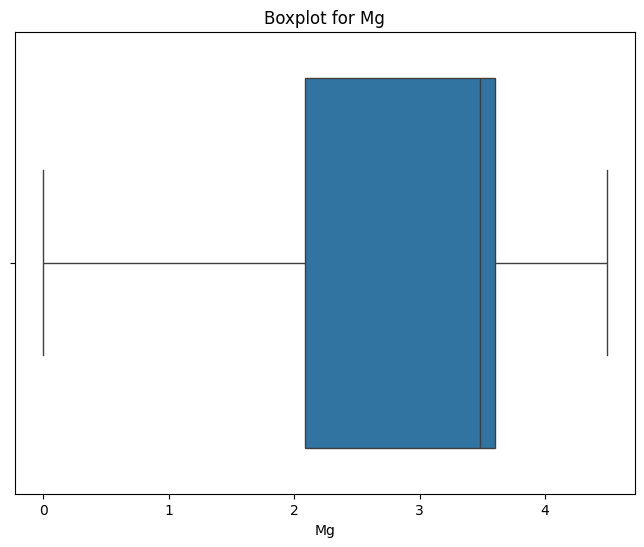

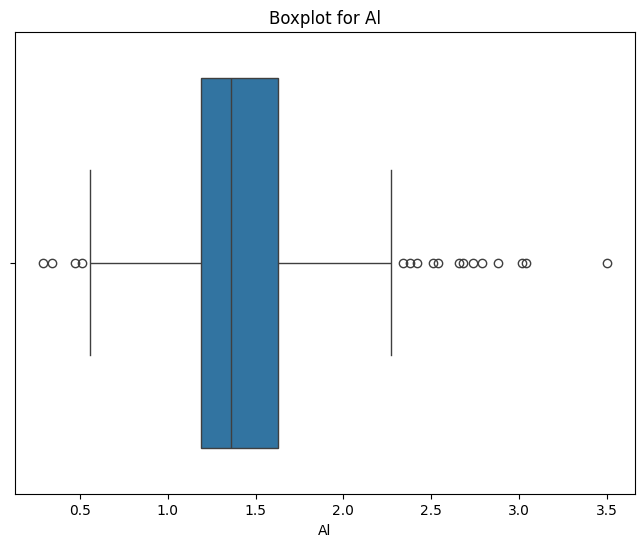

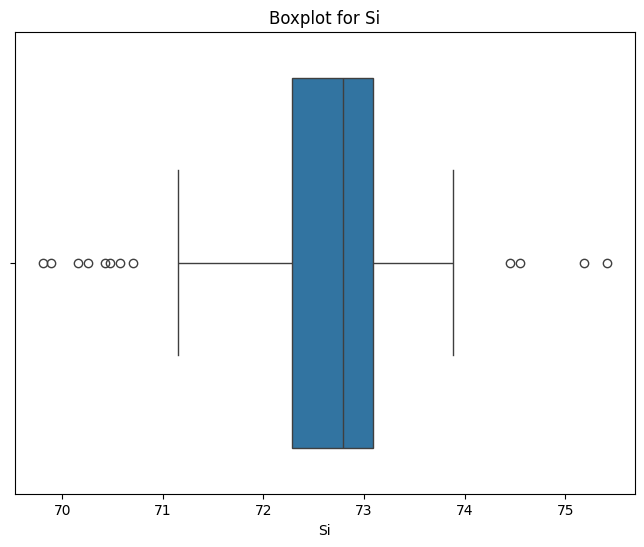

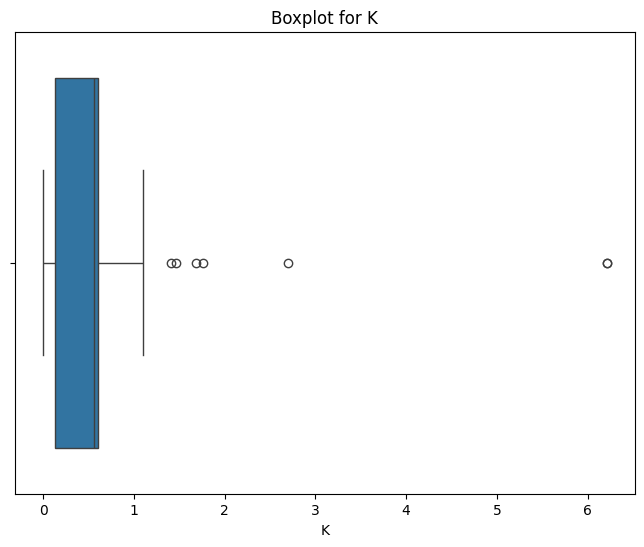

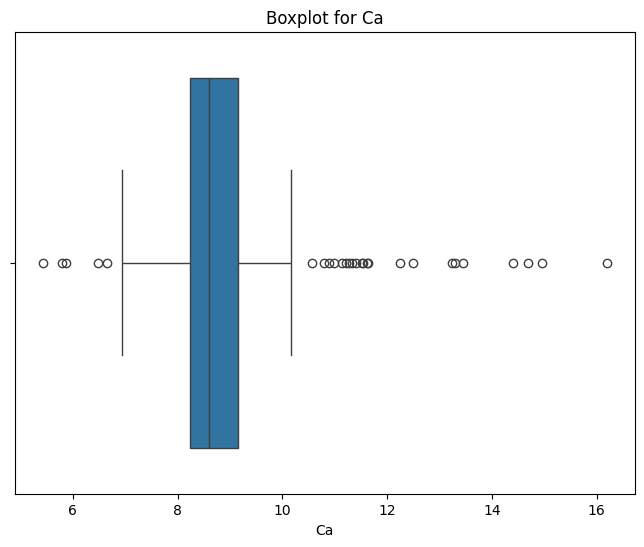

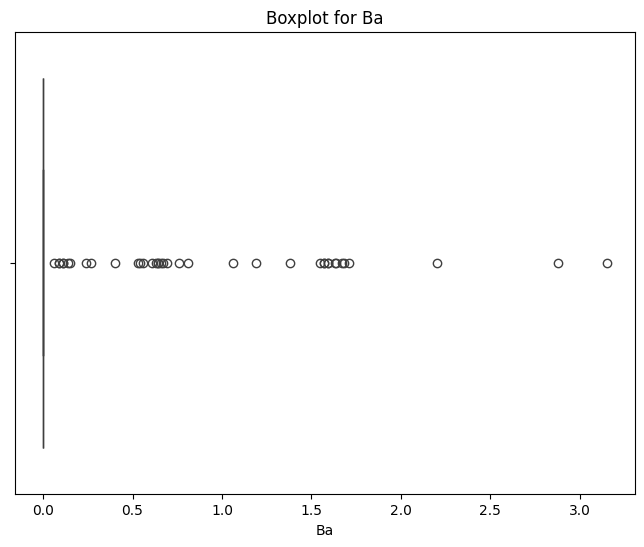

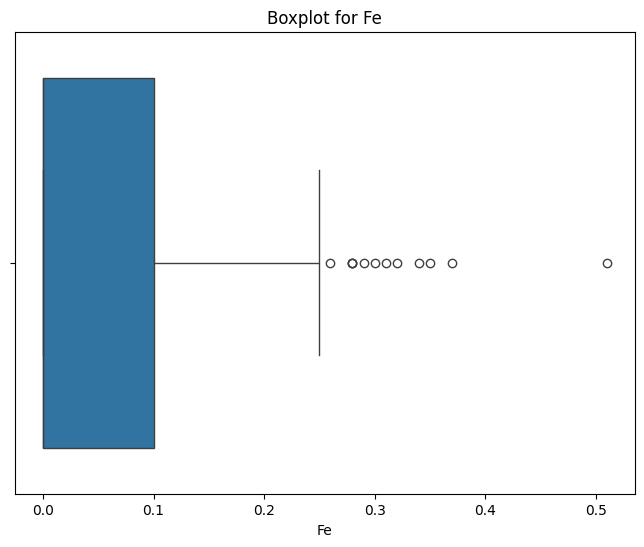

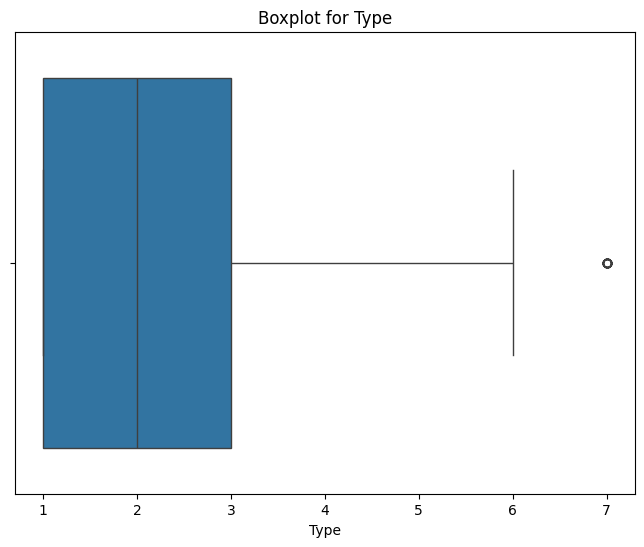

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()

In [ ]:
# Data Cleaning with Outlier Replacement
def replace_outliers(data, colname):
    q1 = data[colname].quantile(0.25)
    q3 = data[colname].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)

    # Identify outliers
    outliers = (df[colname] < lower) | (df[colname] > upper)

    # Replace outliers with upper and lower bounds
    df[colname][outliers] = df[colname][outliers].apply(lambda x: upper if x > upper else lower)

    return data

In [ ]:
df = replace_outliers(df, 'RI')
df=replace_outliers(df,'Na')
df=replace_outliers(df,'Mg')
df=replace_outliers(df,'Al')
df=replace_outliers(df,'Si')
df=replace_outliers(df,'K')
df=replace_outliers(df,'Ca')
df=replace_outliers(df,'Ba')
df=replace_outliers(df,'Fe')
df=replace_outliers(df,'Type')

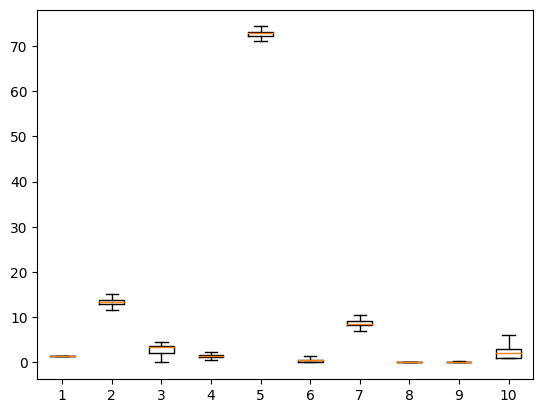

In [ ]:

plt.boxplot(df)
plt.show()


In [ ]:
y = df['Type']
X = df.iloc[:, 1:9]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.71875
